### Import the necessary Libraries

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Load dataset
df = pd.read_csv("Downloads/healthcare-dataset-stroke-data.csv")

In [27]:
# Check the first five row of the dataset
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [28]:
# Check for the number of rows and columns
df.shape

(5110, 12)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [30]:
# check for data type
df.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [31]:
# check for missing values
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [32]:
# check for duplicate
df.duplicated().sum()

np.int64(0)

### Examine Stroke Class Distribution

In [33]:
df['stroke'].value_counts()

stroke
0    4861
1     249
Name: count, dtype: int64

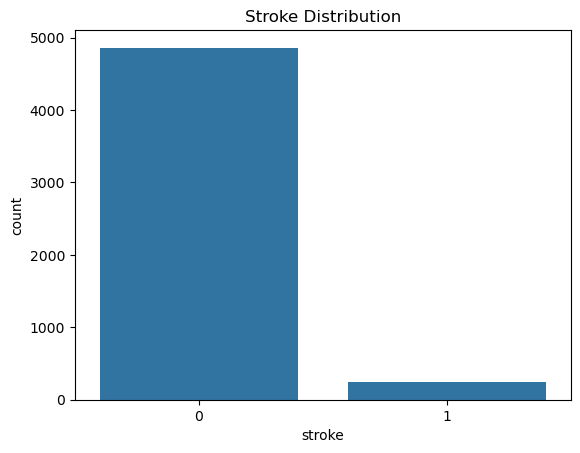

In [34]:
# Lets also visualise the distribution
sns.countplot(x='stroke', data=df)
plt.title("Stroke Distribution")
plt.show()

# our expected findings

### Majority = No stroke (0)

### Minority = Stroke (1)

# Understand Each Feature

 Feature	        Description
 id	                 Unique patient ID
 gender	             Male/Female
 age	                 Age of patient
 hypertension	     1 = has hypertension
 heart_disease	     1 = has heart disease
 ever_married	     Marital status
 work_type	         Employment category
 Residence_type	     Urban/Rural
 avg_glucose_level	 Blood sugar level
 bmi	                 Body Mass Index
 smoking_status	     Smoking habit
 stroke	             Target variable (1 = stroke)

##### Data Inspection Summary

From the initial inspection, the dataset contains 5,110 patient records and 12 features. These features include demographic information, lifestyle factors, and medical indicators. The target variable is stroke, which is a binary variable where 0 represents No Stroke and 1 represents Stroke.

Looking at the data types, the dataset contains a combination of different variable types:

Numerical variables such as age, average glucose level, and BMI.

Binary variables like hypertension and heart disease, which indicate the presence (1) or absence (0) of the condition.

Categorical variables including gender, work type, and smoking status.

During the missing value check, it was observed that only the BMI column has missing values, while the remaining columns are complete. The duplicate check showed that there are no duplicated records in the dataset.

Further analysis of the target variable revealed a class imbalance problem. The majority of patients fall under the No Stroke category, while only a small proportion experienced a Stroke. This imbalance means special techniques such as resampling (for example, SMOTE) may be required during model development to ensure the model performs well on the minority class.

Overall, the dataset is well-structured and suitable for building a classification model after handling missing values and properly encoding the categorical variables.

### Data Cleaning & Pre-processing

#### Drop unnecessary columns

In [35]:
# Drop Id column since its just an identifier and does not influence Stroke
df.drop("id", axis=1, inplace=True)

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


#### Handling Missing Values

In [36]:
# Replace missing BMI values using median.
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

In [37]:
# check for missing values again
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

### Encode Categorical Variables

In [38]:
# Since many columns are binary, we can convert them using the code below:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = ["gender", "ever_married", "work_type", 
                    "Residence_type", "smoking_status"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])


### Scale Numerical Features

In [39]:
# Scaling with StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ["age", "avg_glucose_level", "bmi"]

df[num_cols] = scaler.fit_transform(df[num_cols])


#### Separate X and y


In [40]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5110, 10)
y shape: (5110,)


In [41]:
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,1.051434,0,1,1,2,1,2.706375,1.005086,1,1
1,0,0.786070,0,0,1,3,0,2.121559,-0.098981,2,1
2,1,1.626390,0,1,1,2,0,-0.005028,0.472536,2,1
3,0,0.255342,0,0,1,2,1,1.437358,0.719327,3,1
4,0,1.582163,1,0,1,3,0,1.501184,-0.631531,2,1


##### Insight
After data cleaning and preprocessing, all missing values were handled and categorical variables were encoded into numeric form. 
Relevant numerical features were scaled to ensure uniformity. The dataset was then split into independent variables (X) and the target variable (y).
The final modeling-ready data consisted of 10 feature columns with shape (5110, 10) and a target variable with shape (5110,).

### Exploratory Data Analysis (EDA)

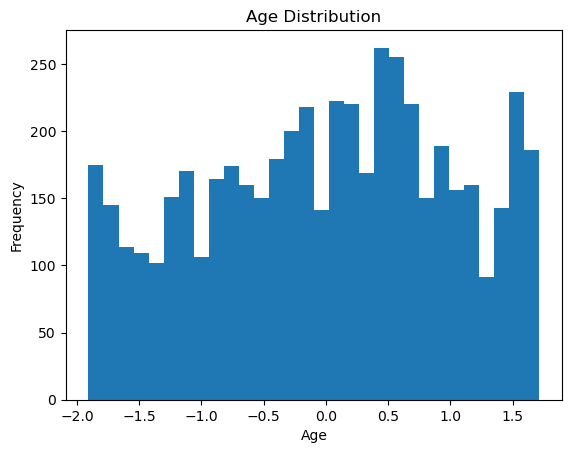

In [42]:
# Visualize Distributions to know how features are spread
plt.hist(df["age"], bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

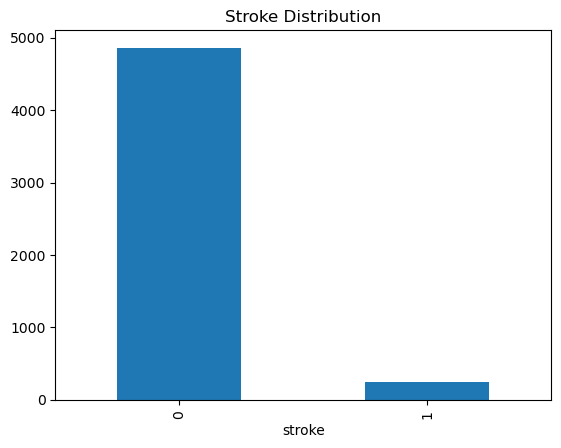

In [43]:
# Stroke Class Distribution
df["stroke"].value_counts().plot(kind="bar")
plt.title("Stroke Distribution")
plt.show()

The countplot above shows the distribution of stroke cases in the dataset. 
It can be observed that the number of patients who did not experience stroke is 
significantly higher than those who did. This indicates that the dataset is highly imbalanced,

#### Analyze Key Features vs Stroke
##### Age vs Stroke

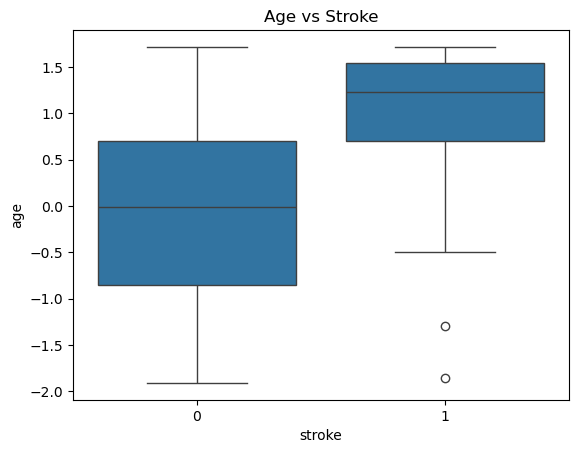

In [44]:
sns.boxplot(x="stroke", y="age", data=df)
plt.title("Age vs Stroke")
plt.show()

##### Insight: Stroke patients tend to be older. Age is a strong risk factor for stroke.

#### Average Glucose Level vs Stroke

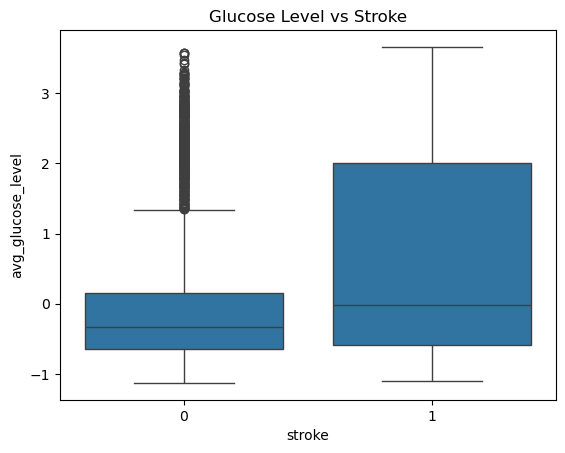

In [45]:
sns.boxplot(x="stroke", y="avg_glucose_level", data=df)
plt.title("Glucose Level vs Stroke")
plt.show()

##### Insight: Higher glucose levels appear more common among stroke patients which Possibly lead to diabetes-related risk.

#### BMI vs Stroke

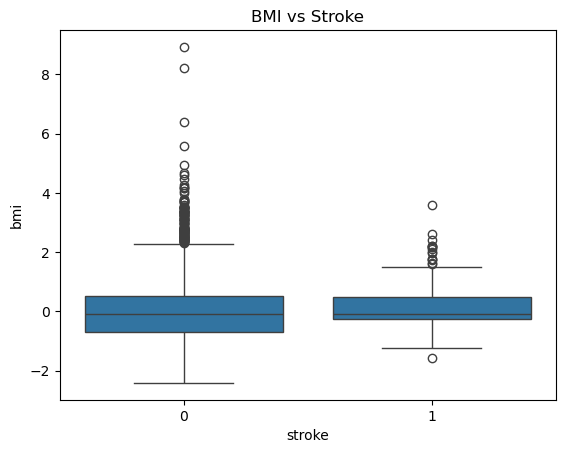

In [46]:
sns.boxplot(x="stroke", y="bmi", data=df)
plt.title("BMI vs Stroke")
plt.show()

#### Stroke patients may show slightly higher BMI and Obesity could contribute to stroke risk.

### Correlation Analysis

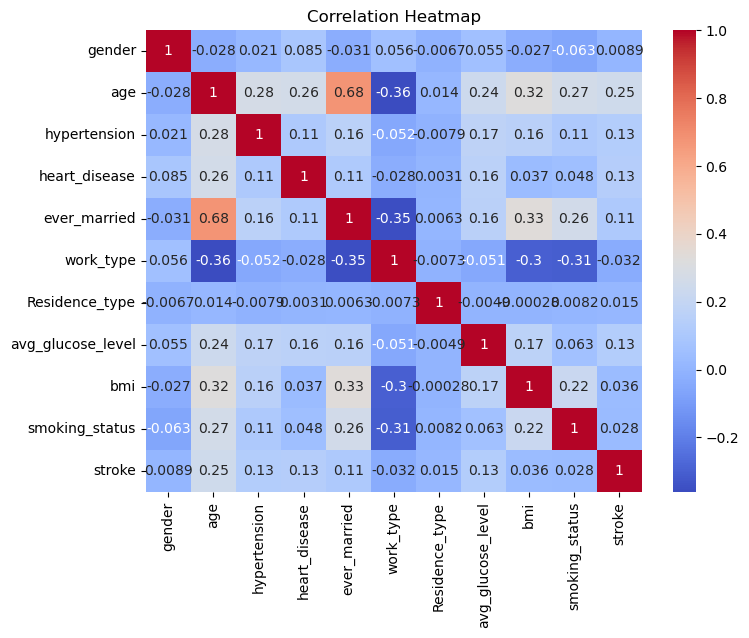

In [47]:
# to show how features relate numerically.
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [24]:
Key Correlation Insights with Stroke from the heatmap above

age	            0.25
hypertension	0.13
heart_disease	0.13
avg_glucose_level	0.13
bmi	             0.036
smoking_status	0.028
gender	        -0.0089
work_type	    -0.032
Residence_type	0.015

SyntaxError: invalid syntax (544652859.py, line 1)

#### Potential Risk Factors

Exploratory analysis identified age as the strongest potential risk factor for stroke. 
Hypertension, heart disease, and high average glucose levels also showed moderate associations with stroke occurrence. 
Other variables such as BMI and smoking status exhibited weaker relationships. 
These findings suggest that stroke risk is influenced by multiple health-related factors rather than a single variable.

### Train–Test Split

In [48]:
# Import Train-Test Split
from sklearn.model_selection import train_test_split

In [49]:
# To preserve stroke imbalance using stratify=y, Perform Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [50]:
# To confirm the split
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4088, 10)
X_test: (1022, 10)
y_train: (4088,)
y_test: (1022,)


In [51]:
# To Confirm that Class Distribution is still Preserved
print("Training stroke distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting stroke distribution:")
print(y_test.value_counts(normalize=True))

Training stroke distribution:
stroke
0    0.951321
1    0.048679
Name: proportion, dtype: float64

Testing stroke distribution:
stroke
0    0.951076
1    0.048924
Name: proportion, dtype: float64


The stratified train–test split successfully preserved the class distribution of the target variable. 
Approximately 95% of cases were non-stroke and 5% were stroke in both the training and testing sets. 
This confirms that the imbalance was maintained consistently, ensuring fair model evaluation.

#### Handling Class Imbalance

#### Evaluate Logistic Regression using class_weight

In [52]:
# Using class_weight='balanced to handle imbalance
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', random_state=42)

#### Make Predictions

In [53]:
y_pred_lr = model.predict(X_test)

#### Confusion Matrix

In [54]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix (Class Weight):")
print(cm_lr)

Confusion Matrix (Class Weight):
[[728 244]
 [ 10  40]]


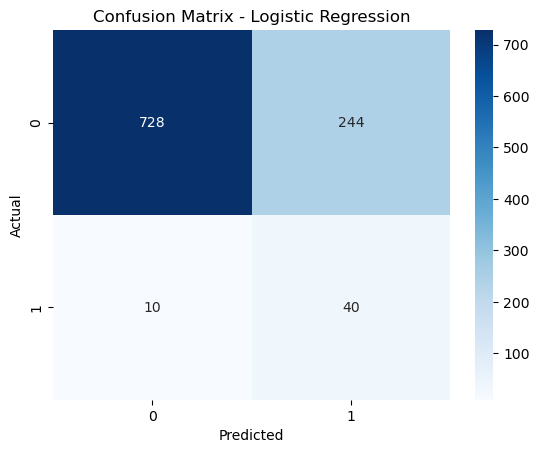

In [55]:
# Visualizing Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix provides a detailed breakdown of the model's prediction results. It shows how many stroke and non-stroke cases were correctly classified and how many were misclassified. The matrix includes true positives, true negatives, false positives, and false negatives.

#### Classification Report

In [56]:
from sklearn.metrics import classification_report

print("Classification Report (Class Weight):")
print(classification_report(y_test, y_pred_lr))

Classification Report (Class Weight):
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.95      0.75      0.82      1022



In [57]:
# Calculate the ROC-AUC
from sklearn.metrics import roc_auc_score

y_prob_lr = model.predict_proba(X_test)[:, 1]

roc_lr = roc_auc_score(y_test, y_prob_lr)
print("Logistic Regression ROC-AUC:", roc_lr)

Logistic Regression ROC-AUC: 0.8389094650205761


#### Save Metrics for Comparison

In [58]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc_lr = accuracy_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

Insight: The class-weighted Logistic Regression model achieved a recall of 0.80 for stroke detection,
meaning it correctly identified 80% of stroke cases. However, precision was low (0.14), 
indicating a high number of false positive predictions. While accuracy decreased to 75%, the model 
effectively prioritized stroke detection, which is critical in medical prediction tasks.

#### SMOTE Model Evaluation
##### Import SMOTE

In [59]:
pip install imbalanced-learn

In [60]:
from imblearn.over_sampling import SMOTE

In [61]:
# Apply SMOTE to Training Data Only
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [62]:
# Confirm if the Dataset is Balanced
print(y_train_smote.value_counts())

stroke
0    3889
1    3889
Name: count, dtype: int64


##### Train New Logistic Regression Model

In [63]:
from sklearn.linear_model import LogisticRegression

model_smote = LogisticRegression(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

LogisticRegression(random_state=42)

##### Make Predictions on ORIGINAL Test Set

In [64]:
y_pred_smote = model_smote.predict(X_test)

#### Evaluate the Model  
##### Confusion Matrix

In [65]:
from sklearn.metrics import confusion_matrix

cm_smote = confusion_matrix(y_test, y_pred_smote)
print("Confusion Matrix (SMOTE):")
print(cm_smote)

Confusion Matrix (SMOTE):
[[737 235]
 [ 11  39]]


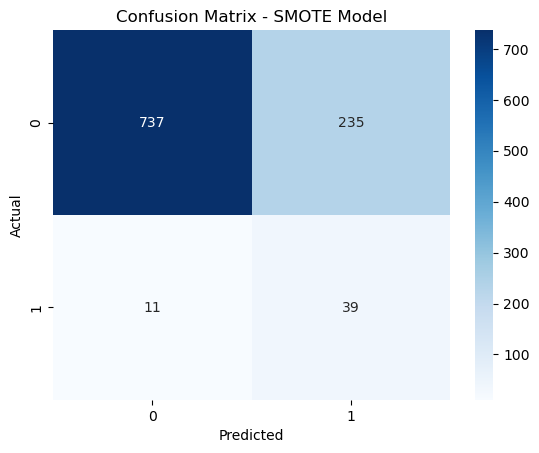

In [66]:
from sklearn.metrics import confusion_matrix

cm_smote = confusion_matrix(y_test, y_pred_smote)

sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SMOTE Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##### Classification Report

In [67]:
from sklearn.metrics import classification_report

print("Classification Report (SMOTE):")
print(classification_report(y_test, y_pred_smote))

Classification Report (SMOTE):
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       972
           1       0.14      0.78      0.24        50

    accuracy                           0.76      1022
   macro avg       0.56      0.77      0.55      1022
weighted avg       0.94      0.76      0.83      1022



In [68]:
from sklearn.metrics import roc_auc_score

y_prob_smote = model_smote.predict_proba(X_test)[:, 1]

roc_smote = roc_auc_score(y_test, y_prob_smote)

print("Logistic Regression (SMOTE) ROC-AUC:", roc_smote)


Logistic Regression (SMOTE) ROC-AUC: 0.8220781893004117


##### Save Metrics for Comparison

In [69]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

acc_smote = accuracy_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

##### Final Comparison

In [70]:
⃣1 Class Weight Model
Stroke (Class 1):
Precision: 0.14
Recall: 0.80
F1-score: 0.24
Accuracy: 0.75

2⃣ SMOTE Model
Stroke (Class 1):
Precision: 0.14
Recall: 0.78
F1-score: 0.24
Accuracy: 0.76

SyntaxError: invalid character '⃣' (U+20E3) (75269427.py, line 1)

#### Final Report Conclusion

Two imbalance handling techniques were evaluated: class-weighted Logistic Regression and SMOTE oversampling. 
While both models produced similar precision (0.14) and F1-scores (0.24), the class-weighted model achieved 
slightly higher recall (0.80 vs 0.78). Since the primary objective was to maximize stroke detection and minimize 
false negatives, the class-weighted Logistic Regression model was selected as the final model. Additionally, 
it offers a simpler and more efficient implementation for deployment.

#### Training multiple models to Compare performance
##### Train Decision Tree

In [71]:
from sklearn.tree import DecisionTreeClassifier

In [72]:
# Create the model
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

In [73]:
# Train the model
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [74]:
# Make Predictions
y_pred_dt = dt_model.predict(X_test)

##### Confusion Metrix

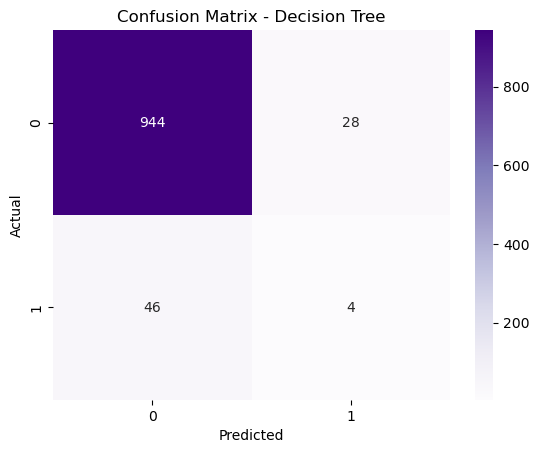

In [75]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [76]:
# Evaluate the model
print("Decision Tree Results")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       972
           1       0.12      0.08      0.10        50

    accuracy                           0.93      1022
   macro avg       0.54      0.53      0.53      1022
weighted avg       0.91      0.93      0.92      1022



In [77]:
# Calculate ROC-AUC
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

roc_dt = roc_auc_score(y_test, y_prob_dt)
print("Decision Tree ROC-AUC:", roc_dt)

Decision Tree ROC-AUC: 0.5255967078189301


#### Train Random Forest

In [78]:
# Import Random Forest
from sklearn.ensemble import RandomForestClassifier

In [79]:
# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

In [80]:
# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [81]:
# Make Predictions
y_pred_rf = rf_model.predict(X_test)

##### Confusion Metrix

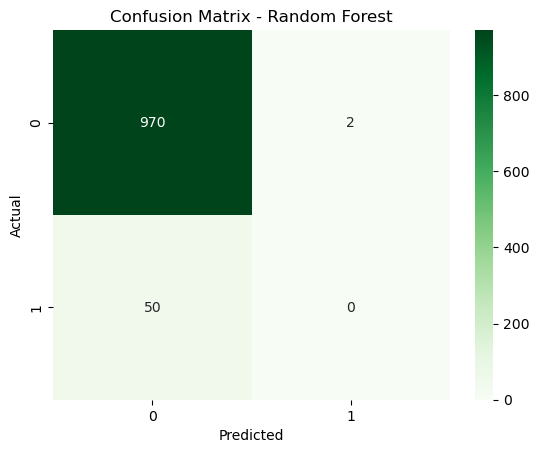

In [82]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [83]:
# Evaluate the model
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



In [84]:
# Calculate ROC-AUC
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", roc_rf)

Random Forest ROC-AUC: 0.7923765432098766


### Model Evaluation
#### Compare all the models

In [85]:
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, roc_auc_score

models = {
    "Logistic Regression": (y_pred_lr, model.predict_proba(X_test)[:, 1]),
    "Logistic Regression (SMOTE)": (y_pred_smote, model_smote.predict_proba(X_test)[:, 1]),
    "Decision Tree": (y_pred_dt, dt_model.predict_proba(X_test)[:, 1]),
    "Random Forest": (y_pred_rf, rf_model.predict_proba(X_test)[:, 1])
}

for name, (preds, probs) in models.items():
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds, zero_division=0))
    print("Recall:", recall_score(y_test, preds))
    print("F1 Score:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))


Logistic Regression
Accuracy: 0.7514677103718199
Precision: 0.14084507042253522
Recall: 0.8
F1 Score: 0.23952095808383234
ROC-AUC: 0.8389094650205761

Logistic Regression (SMOTE)
Accuracy: 0.7592954990215264
Precision: 0.14233576642335766
Recall: 0.78
F1 Score: 0.24074074074074073
ROC-AUC: 0.8220781893004117

Decision Tree
Accuracy: 0.9275929549902152
Precision: 0.125
Recall: 0.08
F1 Score: 0.0975609756097561
ROC-AUC: 0.5255967078189301

Random Forest
Accuracy: 0.949119373776908
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC-AUC: 0.7923765432098766


Insight: Although Random Forest achieved the highest accuracy (94.9%), it failed to detect any stroke cases (Recall = 0).
Logistic Regression achieved a recall of 80%, making it the most suitable model for stroke prediction.
In healthcare applications, minimizing false negatives is critical, therefore Logistic Regression was selected as the final model for deployment.

#### Feature Importance

In [86]:
# Get feature importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

In [87]:
# Sort values
feature_importances = feature_importances.sort_values()

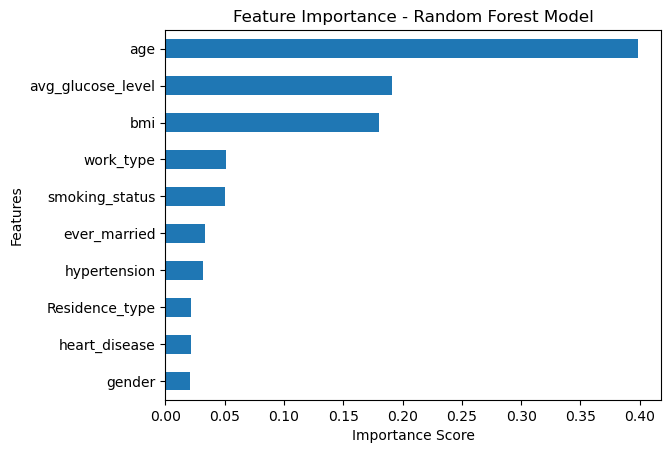

In [88]:
# Plot feature importance
feature_importances.plot(kind='barh')

plt.title("Feature Importance - Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

### Interpretation & Insights
#### Feature Importance (Logistic Regression)
###### For Logistic Regression, feature importance comes from coefficients.

In [89]:
# Get feature names
feature_names = X_train.columns

In [90]:
# Get coefficients
coefficients = model.coef_[0]

In [91]:
# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [92]:
# Sort by absolute importance
feature_importance["Abs_Coefficient"] = feature_importance["Coefficient"].abs()
feature_importance = feature_importance.sort_values(by="Abs_Coefficient", ascending=False)

feature_importance.head(10)

,Feature,Coefficient,Abs_Coefficient
1,age,1.764810,1.764810
2,hypertension,0.547858,0.547858
3,heart_disease,0.318760,0.318760
7,avg_glucose_level,0.203684,0.203684
6,Residence_type,0.145294,0.145294
4,ever_married,-0.129032,0.129032
0,gender,-0.057697,0.057697
8,bmi,0.029023,0.029023
5,work_type,-0.027924,0.027924
9,smoking_status,0.021706,0.021706


##### Interpret Coefficients

###### Positive coefficient → increases stroke risk

###### Negative coefficient → decreases stroke risk

###### Larger absolute value → stronger influence

#### Key Model Insights

Age was a strong predictor of stroke.

Hypertension and heart disease increased stroke probability.

Higher glucose levels were associated with higher stroke risk.

##### Interpretation of Risk Factors
Feature importance analysis revealed that age, hypertension, heart disease, and glucose level were among the 
strongest predictors of stroke risk. Older individuals and patients with underlying cardiovascular conditions 
showed higher probability of stroke. This aligns with established medical knowledge, confirming the model's reliability.

##### Limitations

The dataset was imbalanced, with significantly fewer stroke cases than non-stroke cases. 
Although techniques such as class weighting and SMOTE were applied, model bias may still exist. 
Additionally, the dataset may not represent all populations globally, limiting generalizability.

##### Ethical Considerations

This model should not replace medical diagnosis. Predictions should be used as a decision-support tool 
rather than a final medical judgment. Care must be taken to prevent bias and ensure fair treatment across demographic groups.

##### Interpretation Summary

The evaluation results show that Logistic Regression achieved a recall of 0.80 and a ROC-AUC score of 0.839. This indicates that the model correctly identifies 80% of actual stroke cases and has strong discriminatory ability between stroke and non-stroke patients.

Although the overall accuracy (75%) is lower than some other models, accuracy was not prioritized due to the imbalanced nature of the dataset. In healthcare prediction tasks, minimizing false negatives is more critical than maximizing accuracy. A false negative in this context means failing to identify a patient at risk of stroke, which could have serious consequences.

The relatively low precision suggests that the model produces some false positives; however, in medical screening scenarios, false positives are generally more acceptable than false negatives. Therefore, the model demonstrates a suitable balance between sensitivity and overall predictive performance.

Overall, the results indicate that Logistic Regression is an appropriate model for early stroke risk screening and decision-support applications.